In [1]:
from dotenv import load_dotenv
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

load_dotenv(encoding='utf-8')
engine = create_engine(f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}")

with engine.connect() as conn:
    print("Соединение успешно")

Соединение успешно


In [6]:
with engine.connect() as conn:
    df_rfm = pd.read_sql(text("""
        WITH last_date AS (
            -- Берём последнюю дату в датасете как точку отсчёта
            SELECT MAX("InvoiceDate")::date as max_date
            FROM transactions
        )
        SELECT 
            "Customer ID",
            -- Recency: вычитаем даты — получаем количество дней
            (SELECT max_date FROM last_date) - MAX("InvoiceDate")::date as recency,
            -- Frequency: сколько уникальных заказов
            COUNT(DISTINCT "Invoice") as frequency,
            -- Monetary: общая выручка
            ROUND(SUM("Revenue")::numeric, 2) as monetary
        FROM transactions
        GROUP BY "Customer ID"
        ORDER BY monetary DESC
    """), conn)

print(df_rfm.shape)
print(df_rfm.head(10))

(5862, 4)
   Customer ID  recency  frequency   monetary
0        18102        0        145  580987.04
1        14646        1        145  526751.52
2        14156        9        151  305259.17
3        14911        1        378  280026.15
4        17450        8         51  244784.25
5        13694        3        143  195640.69
6        17511        2         60  172132.87
7        16446        0          2  168472.50
8        16684        4         55  147142.77
9        12415       24         24  144033.37


In [7]:
# Разбиваем на 5 равных групп по каждой метрике
# Recency — чем МЕНЬШЕ тем ЛУЧШЕ, поэтому оценки инвертируем
df_rfm['r_score'] = pd.qcut(df_rfm['recency'], 
                             q=5, 
                             labels=[5, 4, 3, 2, 1])

# Frequency — чем БОЛЬШЕ тем ЛУЧШЕ
df_rfm['f_score'] = pd.qcut(df_rfm['frequency'].rank(method='first'), 
                             q=5, 
                             labels=[1, 2, 3, 4, 5])

# Monetary — чем БОЛЬШЕ тем ЛУЧШЕ
df_rfm['m_score'] = pd.qcut(df_rfm['monetary'].rank(method='first'), 
                             q=5, 
                             labels=[1, 2, 3, 4, 5])

# Переводим в числа
df_rfm['r_score'] = df_rfm['r_score'].astype(int)
df_rfm['f_score'] = df_rfm['f_score'].astype(int)
df_rfm['m_score'] = df_rfm['m_score'].astype(int)

# Итоговый RFM score — среднее трёх оценок
df_rfm['rfm_score'] = (df_rfm['r_score'] + 
                        df_rfm['f_score'] + 
                        df_rfm['m_score']) / 3

print(df_rfm.head(10))

   Customer ID  recency  frequency   monetary  r_score  f_score  m_score  \
0        18102        0        145  580987.04        5        5        5   
1        14646        1        145  526751.52        5        5        5   
2        14156        9        151  305259.17        5        5        5   
3        14911        1        378  280026.15        5        5        5   
4        17450        8         51  244784.25        5        5        5   
5        13694        3        143  195640.69        5        5        5   
6        17511        2         60  172132.87        5        5        5   
7        16446        0          2  168472.50        5        2        5   
8        16684        4         55  147142.77        5        5        5   
9        12415       24         24  144033.37        4        5        5   

   rfm_score  
0   5.000000  
1   5.000000  
2   5.000000  
3   5.000000  
4   5.000000  
5   5.000000  
6   5.000000  
7   4.000000  
8   5.000000  
9   4.666667 

In [17]:
def assign_segment(row):
    r = row['r_score']
    f = row['f_score']
    m = row['m_score']
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Чемпионы'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Лояльные'
    elif r >= 4 and f <= 2:
        return 'Новые клиенты'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'Под угрозой оттока'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Нельзя потерять'
    elif r <= 1 and f <= 2 and m <= 2:
        return 'Потерянные'
    elif m >= 4 and f <= 2:
        return 'Крупные разовые'
    else:
        return 'Обычные'

df_rfm['segment'] = df_rfm.apply(assign_segment, axis=1)

# Смотрим распределение по сегментам
print(df_rfm['segment'].value_counts())

segment
Обычные               1589
Чемпионы              1258
Лояльные              1131
Потерянные             739
Под угрозой оттока     579
Новые клиенты          460
Крупные разовые        106
Name: count, dtype: int64


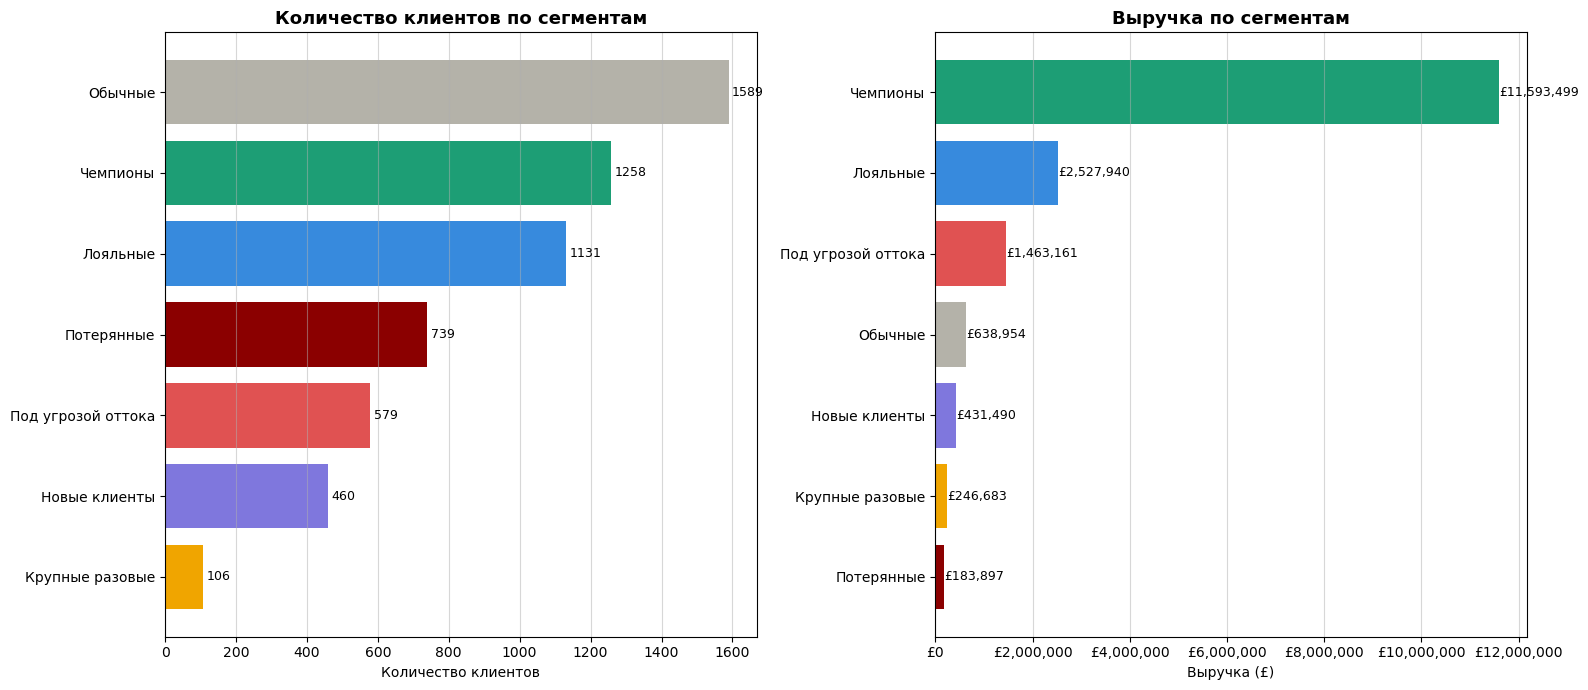

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Цвета для каждого сегмента
colors = {
    'Чемпионы': '#1D9E75',
    'Лояльные': '#378ADD',
    'Новые клиенты': '#7F77DD',
    'Обычные': '#B4B2A9',
    'Крупные разовые': '#F0A500',
    'Под угрозой оттока': '#E05252',
    'Потерянные': '#8B0000'
}

segment_counts = df_rfm['segment'].value_counts()
segment_revenue = df_rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False)

# --- График 1: количество клиентов по сегментам ---
bar_colors = [colors[s] for s in segment_counts.index]
axes[0].barh(segment_counts.index, segment_counts.values,
             color=bar_colors)
for i, value in enumerate(segment_counts.values):
    axes[0].text(value + 10, i, str(value), va='center', fontsize=9)
axes[0].set_title('Количество клиентов по сегментам',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Количество клиентов')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.5)

# --- График 2: выручка по сегментам ---
bar_colors_rev = [colors[s] for s in segment_revenue.index]
axes[1].barh(segment_revenue.index, segment_revenue.values,
             color=bar_colors_rev)
for i, value in enumerate(segment_revenue.values):
    axes[1].text(value + 1000, i, f'£{value:,.0f}',
                 va='center', fontsize=9)
axes[1].set_title('Выручка по сегментам',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Выручка (£)')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.5)

plt.tight_layout()
#plt.savefig('rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

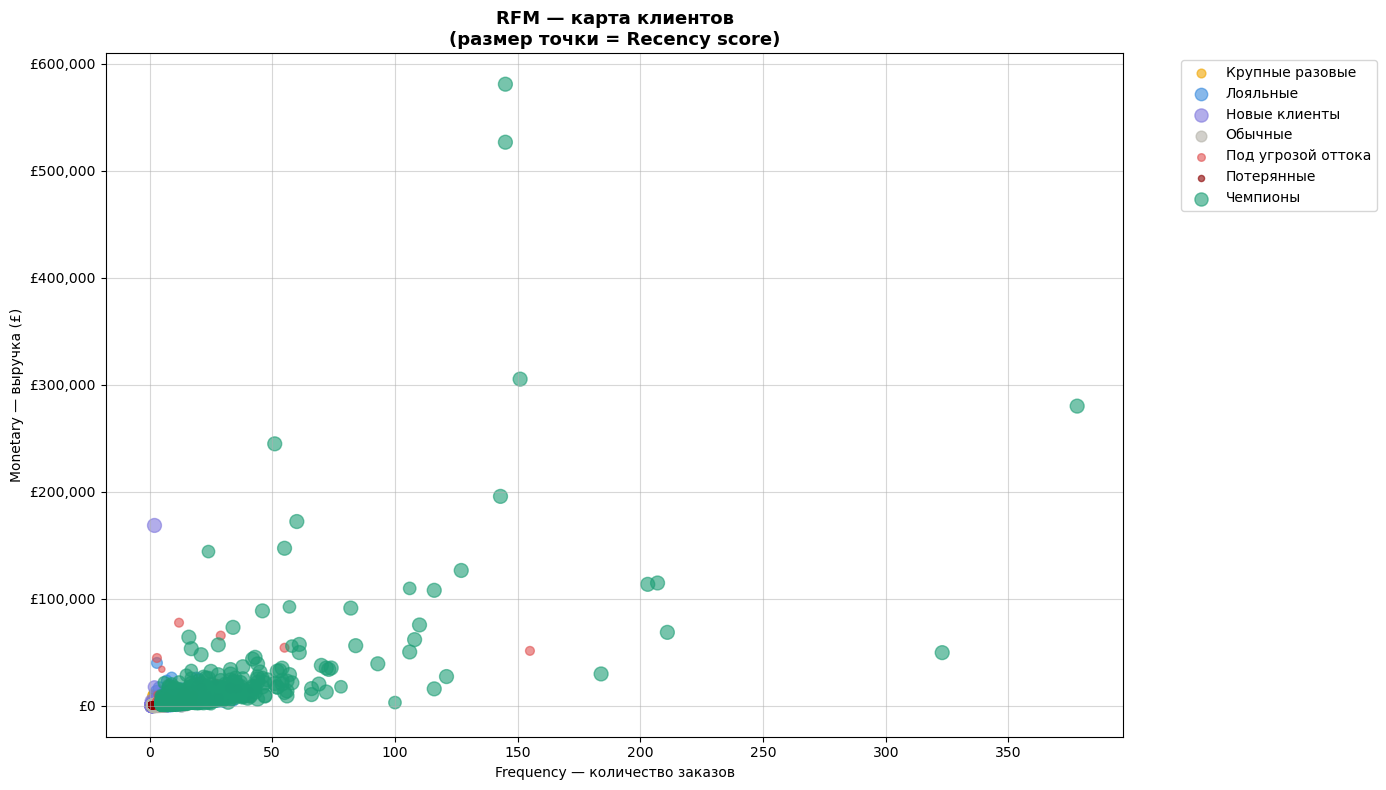

In [32]:
fig, ax = plt.subplots(figsize=(14, 8))

for segment, group in df_rfm.groupby('segment'):
    ax.scatter(
        group['frequency'],
        group['monetary'],
        c=colors[segment],
        label=segment,
        alpha=0.6,
        s=group['r_score'] * 20  # размер точки = recency score
    )

ax.set_title('RFM — карта клиентов\n(размер точки = Recency score)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency — количество заказов')
ax.set_ylabel('Monetary — выручка (£)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.5)

plt.tight_layout()
#plt.savefig('rfm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
Ключевые выводы проекта:

1. Выручка — выраженная сезонность, пик октябрь-ноябрь (+70% к среднему)
2. Топ-20 клиентов генерируют ~18% всей выручки
3. Чемпионы (21% базы) — главный сегмент по выручке
4. 22% клиентской базы под угрозой оттока или уже потеряны
5. Аномалия: PAPER CRAFT — 80к единиц одним заказом